# 01 - Entraînement Multi-Task, 5-Fold et Ensembling avec W&B

**Objectifs de ce notebook :**
1. Créer un Dataset PyTorch qui extrait les deux labels (Marque et Modèle) depuis le nom des fichiers.
2. Définir un modèle ResNet50 avec un tronc commun et deux têtes de classification (MTL).
3. Entraîner 5 versions du modèle via une 5-Fold Cross-Validation stratifiée.
4. Monitorer l'entraînement en temps réel avec Weights & Biases (W&B).
5. Créer la fonction d'extraction finale qui fait la moyenne (Ensembling) des vecteurs des 5 modèles.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import StratifiedKFold
import numpy as np
import wandb
from dotenv import load_dotenv

load_dotenv()

wandb.login(key=os.getenv("WANDB_API_KEY"))

DATA_DIR = "../data/raw/Cars"
BATCH_SIZE = 32
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {DEVICE}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/flavio/.netrc
wandb: Currently logged in as: drogoflavio16 (drogoflavio16-universit-de-mons) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Appareil utilisé : cuda


In [2]:
all_images = [f for f in os.listdir(DATA_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

image_paths = []
brand_labels = []
model_labels = []
composite_labels = []

for img_name in all_images:
    parts = img_name.split('_')
    brand = int(parts[0])
    model = int(parts[1])
    
    image_paths.append(os.path.join(DATA_DIR, img_name))
    brand_labels.append(brand)
    model_labels.append(model)
    composite_labels.append(f"{brand}_{model}")

num_brands = len(set(brand_labels))
num_models = len(set(model_labels))
print(f"Total images : {len(image_paths)} | Marques : {num_brands} | Modèles uniques : {num_models}")

class CarsMTLDataset(Dataset):
    def __init__(self, img_paths, brands, models, transform=None):
        self.img_paths = np.array(img_paths)
        self.brands = np.array(brands)
        self.models = np.array(models)
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        brand = torch.tensor(self.brands[idx], dtype=torch.long)
        model = torch.tensor(self.models[idx], dtype=torch.long)
        
        return image, brand, model

train_transform = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Total images : 10000 | Marques : 10 | Modèles uniques : 10


In [3]:
class MultiTaskResNet(nn.Module):
    def __init__(self, num_brands, num_models):
        super(MultiTaskResNet, self).__init__()
        # Tronc commun
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.shared_backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        # Têtes spécifiques
        self.head_brand = nn.Linear(2048, num_brands)
        self.head_model = nn.Linear(2048, num_models)

    def forward(self, x):
        features = self.shared_backbone(x)
        features = torch.flatten(features, 1) # Descripteur de taille 2048
        
        out_brand = self.head_brand(features)
        out_model = self.head_model(features)
        
        return out_brand, out_model, features

In [4]:
# Initialisation du K-Fold Stratifié
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# On va sauvegarder les chemins vers les meilleurs poids de nos 5 modèles
saved_models_paths = []

# La boucle magique !
for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, composite_labels)):
    print(f"\n{'='*20} Début du FOLD {fold+1}/5 {'='*20}")
    
    # 1. Initialisation de la session W&B pour ce Fold
    run = wandb.init(
        project="cars-retrieval-g05",
        group="MTL-ResNet50-5Fold",
        name=f"Fold_{fold+1}",
        config={"batch_size": BATCH_SIZE, "epochs": EPOCHS, "fold": fold+1}
    )
    
    # 2. Préparation des DataLoaders
    train_dataset = CarsMTLDataset(
        [image_paths[i] for i in train_idx], 
        [brand_labels[i] for i in train_idx], 
        [model_labels[i] for i in train_idx], 
        transform=train_transform
    )
    val_dataset = CarsMTLDataset(
        [image_paths[i] for i in val_idx], 
        [brand_labels[i] for i in val_idx], 
        [model_labels[i] for i in val_idx], 
        transform=val_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # 3. Initialisation du Modèle, Loss et Optimiseur
    model = MultiTaskResNet(num_brands, num_models).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    best_val_loss = float('inf')
    model_save_path = f"best_model_fold_{fold+1}.pth"
    
    # 4. Boucle d'entraînement
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        
        for images, brands, models_target in train_loader:
            images, brands, models_target = images.to(DEVICE), brands.to(DEVICE), models_target.to(DEVICE)
            
            optimizer.zero_grad()
            out_brand, out_model, _ = model(images)
            
            # La Loss est la somme des deux tâches !
            loss_brand = criterion(out_brand, brands)
            loss_model = criterion(out_model, models_target)
            loss = loss_brand + loss_model
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # 5. Boucle de validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, brands, models_target in val_loader:
                images, brands, models_target = images.to(DEVICE), brands.to(DEVICE), models_target.to(DEVICE)
                out_brand, out_model, _ = model(images)
                loss = criterion(out_brand, brands) + criterion(out_model, models_target)
                val_loss += loss.item()
                
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Envoi des métriques à W&B en direct !
        wandb.log({
            "epoch": epoch+1, 
            "train_loss": avg_train_loss, 
            "val_loss": avg_val_loss
        })
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Early Stopping local : Sauvegarde du meilleur modèle du fold
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_save_path)
            
    saved_models_paths.append(model_save_path)
    wandb.finish() # Termine la session pour ce fold


==================== Début du FOLD 1/5 ====================


/home/flavio/Documents/Github/Machine-and-DeepLearning-for-Multimedia-Retrieval/.venv/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/100 | Train Loss: 4.0481 | Val Loss: 2.8972
Epoch 2/100 | Train Loss: 2.7842 | Val Loss: 1.9349
Epoch 3/100 | Train Loss: 2.1384 | Val Loss: 1.4115
Epoch 4/100 | Train Loss: 1.7391 | Val Loss: 1.1182
Epoch 5/100 | Train Loss: 1.4577 | Val Loss: 0.9357
Epoch 6/100 | Train Loss: 1.2689 | Val Loss: 0.8849
Epoch 7/100 | Train Loss: 1.1166 | Val Loss: 0.7906
Epoch 8/100 | Train Loss: 1.0445 | Val Loss: 0.7038
Epoch 9/100 | Train Loss: 0.9738 | Val Loss: 0.6758
Epoch 10/100 | Train Loss: 0.9183 | Val Loss: 0.6595
Epoch 11/100 | Train Loss: 0.8319 | Val Loss: 0.6268
Epoch 12/100 | Train Loss: 0.7870 | Val Loss: 0.6202
Epoch 13/100 | Train Loss: 0.7211 | Val Loss: 0.6040
Epoch 14/100 | Train Loss: 0.7171 | Val Loss: 0.6227
Epoch 15/100 | Train Loss: 0.6716 | Val Loss: 0.6115
Epoch 16/100 | Train Loss: 0.6585 | Val Loss: 0.5666
Epoch 17/100 | Train Loss: 0.6372 | Val Loss: 0.6243
Epoch 18/100 | Train Loss: 0.6183 | Val Loss: 0.6851
Epoch 19/100 | Train Loss: 0.5924 | Val Loss: 0.6071
Ep

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
train_loss,0.28856
val_loss,0.60249



==================== Début du FOLD 2/5 ====================


...

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇████
train_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
train_loss,0.28119
val_loss,0.52558



==================== Début du FOLD 5/5 ====================


/home/flavio/Documents/Github/Machine-and-DeepLearning-for-Multimedia-Retrieval/.venv/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/100 | Train Loss: 4.0336 | Val Loss: 2.7960
Epoch 2/100 | Train Loss: 2.7536 | Val Loss: 1.9366
Epoch 3/100 | Train Loss: 2.0955 | Val Loss: 1.4152
Epoch 4/100 | Train Loss: 1.7252 | Val Loss: 1.1520
Epoch 5/100 | Train Loss: 1.4536 | Val Loss: 0.9811
Epoch 6/100 | Train Loss: 1.2844 | Val Loss: 0.9098
Epoch 7/100 | Train Loss: 1.1257 | Val Loss: 0.8469
Epoch 8/100 | Train Loss: 1.0281 | Val Loss: 0.7860
Epoch 9/100 | Train Loss: 0.9683 | Val Loss: 0.7544
Epoch 10/100 | Train Loss: 0.8663 | Val Loss: 0.6737
Epoch 11/100 | Train Loss: 0.8645 | Val Loss: 0.7057
Epoch 12/100 | Train Loss: 0.7681 | Val Loss: 0.6631
Epoch 13/100 | Train Loss: 0.7314 | Val Loss: 0.6611
Epoch 14/100 | Train Loss: 0.7178 | Val Loss: 0.6744
Epoch 15/100 | Train Loss: 0.7201 | Val Loss: 0.6382
Epoch 16/100 | Train Loss: 0.6598 | Val Loss: 0.6119
Epoch 17/100 | Train Loss: 0.6578 | Val Loss: 0.5948
Epoch 18/100 | Train Loss: 0.6399 | Val Loss: 0.5965
Epoch 19/100 | Train Loss: 0.6374 | Val Loss: 0.6094
Ep

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train_loss,█▇▅▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
train_loss,0.267
val_loss,0.59248


In [5]:
# On crée une liste de nos 5 modèles entraînés
ensemble_models = []
for path in saved_models_paths:
    m = MultiTaskResNet(num_brands, num_models)
    m.load_state_dict(torch.load(path))
    m.to(DEVICE)
    m.eval() # Mode évaluation strict
    ensemble_models.append(m)

print("Les 5 modèles ont été chargés pour l'ensembling !")

def extract_ensemble_descriptor(img_path):
    """
    Prend une image, la passe dans les 5 modèles, 
    et fait la moyenne de leurs vecteurs de 2048 dimensions.
    """
    image = Image.open(img_path).convert('RGB')
    input_tensor = val_transform(image).unsqueeze(0).to(DEVICE) # On utilise val_transform (sans data augmentation)
    
    all_features = []
    with torch.no_grad():
        for m in ensemble_models:
            _, _, features = m(input_tensor) # On ne récupère que le 3ème élément : le tronc commun (2048)
            all_features.append(features.cpu().squeeze())
            
    # Empile les 5 tenseurs et fait la moyenne sur la dimension 0 (les modèles)
    stacked_features = torch.stack(all_features)
    final_descriptor = torch.mean(stacked_features, dim=0)
    
    return final_descriptor.numpy()

# Test sur l'image R1 de votre groupe !
test_img = os.path.join(DATA_DIR, "0_1_BMW_X3_207.jpg")
if os.path.exists(test_img):
    descriptor = extract_ensemble_descriptor(test_img)
    print(f"Taille du descripteur final (Ensemble de 5 modèles) : {descriptor.shape}")

Les 5 modèles ont été chargés pour l'ensembling !
Taille du descripteur final (Ensemble de 5 modèles) : (2048,)


Chargement des descripteurs existants depuis le disque...

Extraction du descripteur pour la requête : 0_1_BMW_X3_207.jpg

--- Résultats Top-100 récupérés. Affichage du Top-10 ---


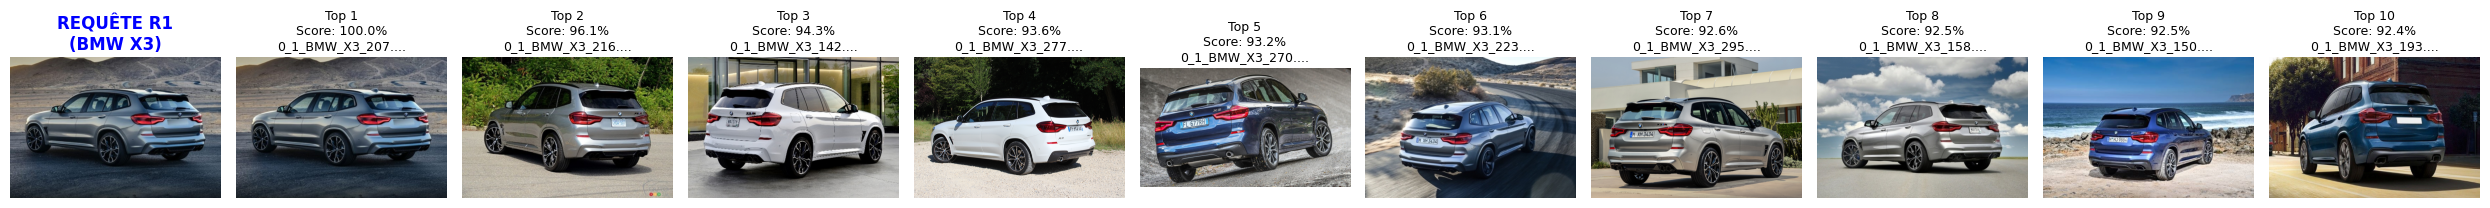

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import os
from tqdm import tqdm # Pour la barre de progression
from PIL import Image

# 1. INDEXATION DE LA BASE DE DONNÉES RÉELLE
# Cette étape extrait les descripteurs pour les ~14k images. 
# On sauvegarde le résultat pour éviter de tout recalculer aux prochains lancements.
features_file = "db_features_ensemble.npy"
paths_file = "db_paths_ensemble.npy"

if os.path.exists(features_file) and os.path.exists(paths_file):
    print("Chargement des descripteurs existants depuis le disque...")
    db_features = np.load(features_file)
    db_paths = np.load(paths_file)
else:
    print("Extraction des descripteurs pour toute la base de données (Indexation)...")
    db_features_list = []
    db_paths_list = []
    
    # image_paths est la liste de toutes tes images définie plus haut dans ton notebook
    for img_path in tqdm(image_paths, desc="Indexation en cours"):
        desc = extract_ensemble_descriptor(img_path)
        db_features_list.append(desc)
        db_paths_list.append(img_path)
        
    db_features = np.array(db_features_list)
    db_paths = np.array(db_paths_list)
    
    # Sauvegarde sur le disque
    np.save(features_file, db_features)
    np.save(paths_file, db_paths)
    print("Indexation terminée et sauvegardée !")

# 2. FONCTION DE RECHERCHE MULTI-MÉTRIQUES
def retrieve_similar_images(query_desc, db_feats, db_img_paths, top_k=50, metric='cosine'):
    """
    Recherche les images similaires en laissant le choix de la métrique.
    """
    query_desc_reshaped = query_desc.reshape(1, -1)
    
    if metric == 'cosine':
        # Similarité cosinus (plus c'est proche de 1, mieux c'est)
        similarities = cosine_similarity(query_desc_reshaped, db_feats)[0]
        top_indices = np.argsort(similarities)[::-1][:top_k]
        best_scores = similarities[top_indices]
    elif metric == 'euclidean':
        # Distance euclidienne (plus c'est proche de 0, mieux c'est)
        distances = euclidean_distances(query_desc_reshaped, db_feats)[0]
        top_indices = np.argsort(distances)[:top_k] # Tri croissant pour les distances
        best_scores = distances[top_indices]
    else:
        raise ValueError("Métrique non supportée. Choisissez 'cosine' ou 'euclidean'.")
        
    best_paths = db_img_paths[top_indices]
    
    return best_paths, best_scores

# 3. REQUÊTE R1 (Groupe Impair)
test_img = os.path.join(DATA_DIR, "0_1_BMW_X3_207.jpg")
print(f"\nExtraction du descripteur pour la requête : {os.path.basename(test_img)}")
query_descriptor = extract_ensemble_descriptor(test_img)

# On récupère le Top-50 pour l'évaluation, mais on n'en affichera que 20
TOP_K_EVAL = 100
TOP_K_DISPLAY = 10

# Tu peux changer 'cosine' par 'euclidean' ici pour tester d'autres métriques
results_paths, results_scores = retrieve_similar_images(
    query_descriptor, 
    db_features, 
    db_paths, 
    top_k=TOP_K_EVAL, 
    metric='cosine' 
)

print(f"\n--- Résultats Top-{TOP_K_EVAL} récupérés. Affichage du Top-{TOP_K_DISPLAY} ---")

# 4. AFFICHAGE VISUEL
fig, axes = plt.subplots(1, TOP_K_DISPLAY + 1, figsize=(25, 4))

# Afficher la Requête
img_req = Image.open(test_img)
axes[0].imshow(img_req)
axes[0].set_title("REQUÊTE R1\n(BMW X3)", color="blue", fontweight="bold")
axes[0].axis('off')

# Afficher les Résultats Top-K (les 20 premiers)
for i in range(TOP_K_DISPLAY):
    path = results_paths[i]
    score = results_scores[i]
    
    if os.path.exists(path):
        img_res = Image.open(path)
        axes[i+1].imshow(img_res)
    else:
        axes[i+1].imshow(np.zeros((224, 224, 3), dtype=np.uint8) + 200)
        
    # Formatage du score selon la métrique utilisée
    score_display = f"{score*100:.1f}%" if score <= 1.0 else f"{score:.2f}"
    
    axes[i+1].set_title(f"Top {i+1}\nScore: {score_display}\n{os.path.basename(path)[:15]}...", fontsize=9)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

Chargement des descripteurs existants depuis le disque...

Extraction du descripteur pour la requête : 0_1_BMW_X3_207.jpg

================ ÉVALUATION TOP-150 ================
Classe requêtée (Marque + Modèle) : BMW X3
Images pertinentes dans le Top-150 : 149
Total des images pertinentes dans la DB : 162
Précision@150 : 99.33%
Rappel (Recall)@150 : 91.98%

--- Affichage visuel du Top-10 ---


/tmp/ipykernel_14371/567478243.py:142: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/flavio/Documents/Github/Machine-and-DeepLearning-for-Multimedia-Retrieval/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


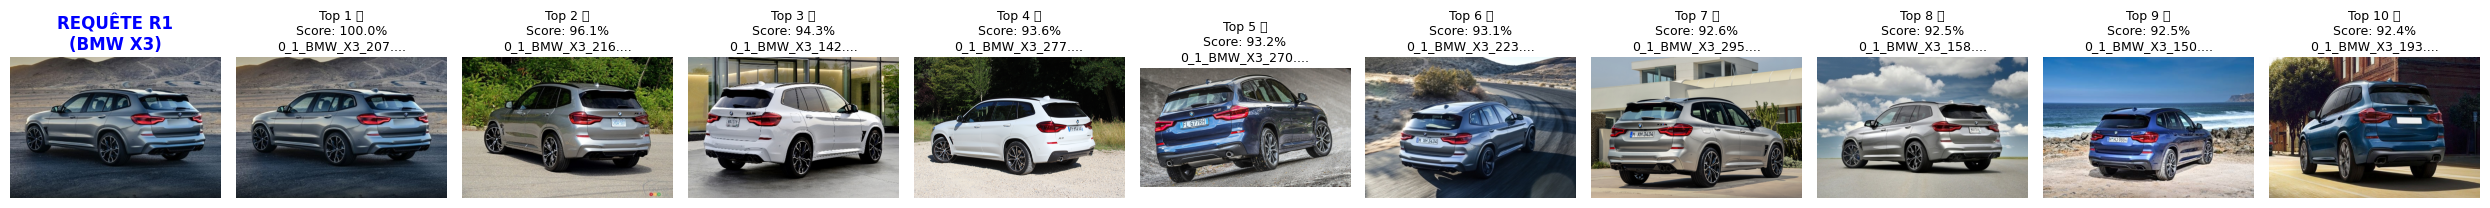

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import os
from tqdm import tqdm # Pour la barre de progression
from PIL import Image

# 1. INDEXATION DE LA BASE DE DONNÉES RÉELLE
features_file = "db_features_ensemble.npy"
paths_file = "db_paths_ensemble.npy"

if os.path.exists(features_file) and os.path.exists(paths_file):
    print("Chargement des descripteurs existants depuis le disque...")
    db_features = np.load(features_file)
    db_paths = np.load(paths_file)
else:
    print("Extraction des descripteurs pour toute la base de données (Indexation)...")
    db_features_list = []
    db_paths_list = []
    
    for img_path in tqdm(image_paths, desc="Indexation en cours"):
        desc = extract_ensemble_descriptor(img_path)
        db_features_list.append(desc)
        db_paths_list.append(img_path)
        
    db_features = np.array(db_features_list)
    db_paths = np.array(db_paths_list)
    
    # Sauvegarde sur le disque
    np.save(features_file, db_features)
    np.save(paths_file, db_paths)
    print("Indexation terminée et sauvegardée !")

# 2. FONCTION DE RECHERCHE MULTI-MÉTRIQUES
def retrieve_similar_images(query_desc, db_feats, db_img_paths, top_k=50, metric='cosine'):
    query_desc_reshaped = query_desc.reshape(1, -1)
    
    if metric == 'cosine':
        similarities = cosine_similarity(query_desc_reshaped, db_feats)[0]
        top_indices = np.argsort(similarities)[::-1][:top_k]
        best_scores = similarities[top_indices]
    elif metric == 'euclidean':
        distances = euclidean_distances(query_desc_reshaped, db_feats)[0]
        top_indices = np.argsort(distances)[:top_k]
        best_scores = distances[top_indices]
    else:
        raise ValueError("Métrique non supportée. Choisissez 'cosine' ou 'euclidean'.")
        
    best_paths = db_img_paths[top_indices]
    
    return best_paths, best_scores

# Fonction utilitaire pour extraire la classe (Marque + Modèle)
def get_class_from_filename(filepath):
    """
    Extrait la marque et le modèle depuis un chemin de fichier.
    Exemple attendu: '.../0_1_BMW_X3_207.jpg' -> Retourne 'BMW_X3'
    """
    filename = os.path.basename(filepath)
    parts = filename.split('_')
    # On assemble l'élément 2 (Marque) et 3 (Modèle)
    if len(parts) >= 4:
        return f"{parts[2]}_{parts[3]}" 
    # Fallback au cas où le nom de fichier n'a pas le bon format
    return filename.split('.')[0] 

# 3. REQUÊTE R1 (Groupe Impair)
# Assurez-vous que DATA_DIR et l'image existent dans votre environnement
test_img = os.path.join(DATA_DIR, "0_1_BMW_X3_207.jpg")
print(f"\nExtraction du descripteur pour la requête : {os.path.basename(test_img)}")
query_descriptor = extract_ensemble_descriptor(test_img)

TOP_K_EVAL = 150
TOP_K_DISPLAY = 10

results_paths, results_scores = retrieve_similar_images(
    query_descriptor, 
    db_features, 
    db_paths, 
    top_k=TOP_K_EVAL, 
    metric='cosine' 
)

# ---------------- NOUVEAU : CALCUL DES MÉTRIQUES (MARQUE + MODÈLE) ----------------
# On définit la classe pertinente de manière stricte : Marque ET Modèle
query_class = get_class_from_filename(test_img)

# 1. Combien y a-t-il d'images de cette classe exacte dans TOUTE la base de données ?
total_relevant_in_db = sum(1 for path in db_paths if get_class_from_filename(path) == query_class)

# 2. Combien y a-t-il d'images de cette classe exacte dans notre TOP_K_EVAL ?
relevant_retrieved = 0
for path in results_paths[:TOP_K_EVAL]:
    res_class = get_class_from_filename(path)
    if res_class == query_class:
        relevant_retrieved += 1

# 3. Calculs
precision = relevant_retrieved / TOP_K_EVAL
recall = relevant_retrieved / total_relevant_in_db if total_relevant_in_db > 0 else 0.0

print(f"\n================ ÉVALUATION TOP-{TOP_K_EVAL} ================")
print(f"Classe requêtée (Marque + Modèle) : {query_class.replace('_', ' ')}")
print(f"Images pertinentes dans le Top-{TOP_K_EVAL} : {relevant_retrieved}")
print(f"Total des images pertinentes dans la DB : {total_relevant_in_db}")
print(f"Précision@{TOP_K_EVAL} : {precision * 100:.2f}%")
print(f"Rappel (Recall)@{TOP_K_EVAL} : {recall * 100:.2f}%")
print("==================================================\n")
# ---------------------------------------------------------------------------------

print(f"--- Affichage visuel du Top-{TOP_K_DISPLAY} ---")

# 4. AFFICHAGE VISUEL
fig, axes = plt.subplots(1, TOP_K_DISPLAY + 1, figsize=(25, 4))

# Afficher la Requête
img_req = Image.open(test_img)
axes[0].imshow(img_req)
axes[0].set_title(f"REQUÊTE R1\n({query_class.replace('_', ' ')})", color="blue", fontweight="bold")
axes[0].axis('off')

# Afficher les Résultats Top-K
for i in range(TOP_K_DISPLAY):
    path = results_paths[i]
    score = results_scores[i]
    
    if os.path.exists(path):
        img_res = Image.open(path)
        axes[i+1].imshow(img_res)
    else:
        axes[i+1].imshow(np.zeros((224, 224, 3), dtype=np.uint8) + 200)
        
    score_display = f"{score*100:.1f}%" if score <= 1.0 else f"{score:.2f}"
    
    # Indication visuelle (V/F) basée sur la classe stricte (Marque + Modèle)
    res_class = get_class_from_filename(path)
    is_correct = "✅" if res_class == query_class else "❌"
    
    axes[i+1].set_title(f"Top {i+1} {is_correct}\nScore: {score_display}\n{os.path.basename(path)[:15]}...", fontsize=9)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()